## Objetivo

El objetivo de este proyecto es aplicar técnicas de Deep Learning a un problema 'distinto' de clasificación en PLN, como por ejemplo el Análisis de Sentimientos.

Para ello, se ha seleccionado el dataset de la quinta edición de [EXIST: sEXism Identification in Social neTworks](https://nlp.uned.es/exist2025/), que formó parte del [CLEF 2025](https://clef2025.clef-initiative.eu/), centrado en la detección de sexismo en redes sociales. La tarea será, por tanto, realizar una clasificación binaria para identificar tweets como sexistas o no sexistas. Se planteará una solución basada en *Deep Learning* mediante el fine-tuning de un modelo Transformer preentrenado para español [BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-uncased).

## Carga del Dataset

En primer lugar, se cargará el dataset. A continuación se definen las rutas de los datos, y debido a que el conjunto de prueba (test) oficial no dispone de etiquetas, se ha designado el conjunto de desarrollo (dev) como el conjunto de evaluación. Como se puede observar, las rutas de las etiquetas y de los datos que contienen el contenido textual (tweets) están separadas debido a la división por tareas de la competición.

In [7]:
import os

base = '2025 EXIST'
datasets_path = base + '/EXIST 2025 Tweets Dataset'
labels_path = base + '/evaluation/golds'

# ruta de los datos de entrenamiento y test
train_path = datasets_path + '/training/EXIST2025_training.json'
test_path = datasets_path + '/dev/EXIST2025_dev.json'

# ruta de las etiquetas de entrenamiento y test
train_labels_path = labels_path + '/EXIST2025_training_task1_1_gold_hard.json'
test_labels_path = labels_path + '/EXIST2025_dev_task1_1_gold_hard.json'

Una vez se tienen las rutas, se cargan los datos de entrenamiento, test y sus etiquetas.

In [8]:
import pandas as pd

# cargar conjuntos de entrenamiento y test
train = pd.read_json(train_path, orient='index')
test = pd.read_json(test_path, orient='index')

# cargar las etiquetas de entrenamiento y test
train_labels = pd.read_json(train_labels_path)
test_labels = pd.read_json(test_labels_path)

A continuación, se puede comprobar que los datos se han cargado correctamente, además de poder comprobar su formato.

In [9]:
train.info()

<class 'pandas.DataFrame'>
Index: 6920 entries, 100001 to 203260
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_EXIST                 6920 non-null   int64 
 1   lang                     6920 non-null   str   
 2   tweet                    6920 non-null   str   
 3   number_annotators        6920 non-null   int64 
 4   annotators               6920 non-null   object
 5   gender_annotators        6920 non-null   object
 6   age_annotators           6920 non-null   object
 7   ethnicities_annotators   6920 non-null   object
 8   study_levels_annotators  6920 non-null   object
 9   countries_annotators     6920 non-null   object
 10  labels_task1_1           6920 non-null   object
 11  labels_task1_2           6920 non-null   object
 12  labels_task1_3           6920 non-null   object
 13  split                    6920 non-null   str   
dtypes: int64(2), object(9), str(3)
memory usage: 2.0+

In [10]:
train.head(2)

,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1_1,labels_task1_2,labels_task1_3,split
100001,100001,es,"@TheChiflis Ignora al otro, es un capullo.El p...",6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, High sc...","[Italy, Mexico, United States, Spain, Spain, C...","[YES, YES, NO, YES, YES, YES]","[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...","[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-V...",TRAIN_ES
100002,100002,es,@ultimonomada_ Si comicsgate se parece en algo...,6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, YES, NO]","[-, -, -, -, DIRECT, -]","[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",TRAIN_ES


In [11]:
test.info()

<class 'pandas.DataFrame'>
Index: 1038 entries, 300001 to 400489
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_EXIST                 1038 non-null   int64 
 1   lang                     1038 non-null   str   
 2   tweet                    1038 non-null   str   
 3   number_annotators        1038 non-null   int64 
 4   annotators               1038 non-null   object
 5   gender_annotators        1038 non-null   object
 6   age_annotators           1038 non-null   object
 7   ethnicities_annotators   1038 non-null   object
 8   study_levels_annotators  1038 non-null   object
 9   countries_annotators     1038 non-null   object
 10  labels_task1_1           1038 non-null   object
 11  labels_task1_2           1038 non-null   object
 12  labels_task1_3           1038 non-null   object
 13  split                    1038 non-null   str   
dtypes: int64(2), object(9), str(3)
memory usage: 315.

In [12]:
test.head(2)

,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1_1,labels_task1_2,labels_task1_3,split
300001,300001,es,@Fichinescu La comunidad gamer es un antro de ...,6,"[Annotator_726, Annotator_727, Annotator_357, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Hispano or Latino, Hispano or Latino, White o...","[High school degree or equivalent, Bachelor’s ...","[Mexico, Chile, Serbia, Portugal, Mexico, Spain]","[NO, YES, YES, NO, YES, NO]","[-, JUDGEMENTAL, JUDGEMENTAL, -, REPORTED, -]","[[-], [MISOGYNY-NON-SEXUAL-VIOLENCE], [MISOGYN...",DEV_ES
300002,300002,es,@anacaotica88 @MordorLivin No me acuerdo de lo...,6,"[Annotator_731, Annotator_732, Annotator_315, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Bachelor’s ...","[Spain, Chile, United Kingdom, Chile, Chile, S...","[YES, YES, NO, YES, YES, YES]","[JUDGEMENTAL, REPORTED, -, JUDGEMENTAL, JUDGEM...","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",DEV_ES


In [13]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 6064 entries, 0 to 6063
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   test_case  6064 non-null   str  
 1   id         6064 non-null   int64
 2   value      6064 non-null   str  
dtypes: int64(1), str(2)
memory usage: 210.0 KB


In [14]:
train_labels.head(2)

,test_case,id,value
0,EXIST2025,100001,YES
1,EXIST2025,100002,NO


In [15]:
test_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   test_case  934 non-null    str  
 1   id         934 non-null    int64
 2   value      934 non-null    str  
dtypes: int64(1), str(2)
memory usage: 32.5 KB


In [16]:
test_labels.head(2)

,test_case,id,value
0,EXIST2025,300002,YES
1,EXIST2025,300003,NO


Una porción de ambos conjuntos están en inglés, idioma que no se tratará en esta tarea puesto que el objetivo es clasificar los tweets en español, lo cual es algo que reducirá los datos sobre los que entrenar y por tanto puede ser un factor que sobre todo, puede afectar al rendimiento de los modelos de *Deep Learning*.

Por otro lado, se pueden eliminar las columnas que no son relevantes y dejar únicamente `id_EXIST` para identificar el tweet, el propio contenido textual en el atributo `tweet` y `value`, es decir la etiqueta que indica si dicho tweet es sexista o no.

In [17]:
# filtrar solo los twits en espanol
train = train[train['lang'] == 'es']
test = test[test['lang'] == 'es']

# filtrar solo las etiquetas de los datos restantes
train_labels = train_labels[train_labels['id'].isin(train['id_EXIST'])]
test_labels = test_labels[test_labels['id'].isin(test['id_EXIST'])]

In [18]:
# unir tweets con sus etiquetas en un solo DataFrame
train = pd.merge(train, train_labels, left_on='id_EXIST', right_on='id')
test = pd.merge(test, test_labels, left_on='id_EXIST', right_on='id')

# eliminar las columnas innecesarias
train = train[['id_EXIST', 'tweet', 'value']]
test = test[['id_EXIST', 'tweet', 'value']]

Una vez que solo quedan los datos necesarios, podemos ver cuantas filas han quedado:

In [19]:
print(f'Filas del conjunto de entrenamiento: {len(train)}')
print(f'Filas del conjunto de test: {len(test)}')

Filas del conjunto de entrenamiento: 3194
Filas del conjunto de test: 490


Como podemos ver, ambos conjuntos se han reducido hasta un poco menos de la mitad del tamaño original. Esto puede afectar al balanceo de ambas clases, por los que se ha de comprobar si existe una proporcion similar de ambas:

In [20]:
train['value'].value_counts(normalize=True)

value
NO     0.511584
YES    0.488416
Name: proportion, dtype: float64

Como se puede comprobar, los datos están balanceados con un 51% de tweets etiquetados como no sexistas y un 48% de tweets sexistas.

## Preprocesado

La siguiente etapa será aplicar el preprocesado a los textos de los tweets de ambos datasets recuperados (entrenamiento y test). En primer lugar, se plantea la segmentación de hashtags, los cuales pueden ser fundamentales para identificar la temática e intención de cada texto.

Por ejemplo, para modelos de *Machine learning* un hashtag como `#MujerTeniasQueSer` es una palabra única que probablemente aparezca poco y sea ignorada, mientras que si se realiza una segmentación en ``mujer``, ``tenias``, ``que``, ``ser``, el modelo puede relacionar estas palabras con otros tweets sexistas. Para modelos de *Deep Learning*, separar un hashtag como `#NiUnaMenos` ayuda a que se enfoque mejor la relación entre ``ni`` y ``menos``, capturando el sentimiento de protesta.

Para realizar esta tarea, se usará la librería ekphrasis usando un corpus extraido de twitter, de modo que se obtiene la siguiente función:

In [21]:
from ekphrasis.classes.segmenter import Segmenter
seg = Segmenter(corpus="twitter")

def segment_hashtag(match):
    # obtener contenido del hashtag sin el '#'
    hashtag_content = match.group(1)
    # Segmentar (ej: "UnTexto" -> "un texto")
    segmented = seg.segment(hashtag_content)
    return segmented

Reading twitter - 1grams ...
Reading twitter - 2grams ...


c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\ekphrasis\classes\exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


En textos de twitter es normal encontrar menciones a usuarios mediante `@usuario`, algo que no aporta información y que se ha eliminar. Para DL, se ha optado por sustituir dichas menciones por la cadena `[USER]` para mantener la relación usuario-tema.

Por otro lado, se suelen encontrar menciones, texto y hashtags 'pegados', como por ejemplo `texto#hashtag` o `@usuario#hashtag`, algo que se ha de separar para poder tratar por separado. En los tweets tambien se han encontrado URLs, las cuales se han eliminado en el preprocesado de ML y en el caso de DL, se ha sustituido por la cadena `[URL]`.

In [22]:
import re

def preprocess(text: str):
    # separar hashtags y menciones pegadas
    text = re.sub(r'([^\s])([#@])', r'\1 \2', text)

    # sustituir las URLs del texto por [URL], primero
    # separando las que estan pegadas en el texto
    text =  re.sub(r'(\w+)(https?://)', r'\1 \2', text)
    text = re.sub(r'https?://[^\s]+', '[URL]', text)

    # sustituir menciones a usuarios por [USER]
    text = re.sub(r'@\w+', '[USER]', text)

    # quitar el '#' de los hashtags y segmentarlos
    text = re.sub(r'#(\w+)', segment_hashtag, text)
    return text

Una vez se tienen dichas funciones de preprocesado, se crean nuevas columnas con el texto limpio.

In [23]:
# preprocesar el conjunto de entrenamiento y test
train['tweet_clean'] = train['tweet'].apply(preprocess)
test['tweet_clean'] = test['tweet'].apply(preprocess)

En primer lugar, se obtienen los ejes sobre el conjunto de entrenamiento y test. El eje X serán los textos de los tweets mientras que el eje Y serán las etiquetas.

In [24]:
# obtener los ejes x,y
x_train = train['tweet_clean']
y_train = train['value']

x_test = test['tweet_clean']
y_test = test['value']

## Modelos DL

Puesto que más adelante se necesitará, se calculan diccionarios para pasar de etiquetas a número y viceversa:

In [25]:
label2id = {'NO': 0, 'YES': 1}
id2label = {0: 'NO', 1: 'YES'}

y_train_dl = y_train.map(label2id)
y_test_dl = y_test.map(label2id)

Una vez contamos con las herramientas, es hora de especificar el modelo DL al que se le aplicará el fine-tunning. Este será [BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased). Este modelo es de tipo [BERT](https://github.com/google-research/bert) (Bidirectional Encoder Representations from Transformers), específicamente entrenado en español y en concreto el modelo `bert-base-spanish-wwm-cased` para textos en minúscula, el cual es nuestro caso.

A continuación, se ha de definir una clase para que PyTorch pueda acceder al dataset. En concreto, esta clase actúa como una interfaz entre los datos (un DataFrame de Pandas) y el modelo de Deep Learning (BETO).

In [26]:
import torch

class EXISTDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Una vez se cuenta con dicha clase, se encapsulan los datos de entrenamiento y test.

In [27]:
from transformers import AutoTokenizer

# obtener el tokenizador a partir del modelo
model_name = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# tokenizar datos de entrenamiento y test
train_encodings = tokenizer(x_train.tolist(), truncation=True, 
    padding=True, max_length=128)

test_encodings = tokenizer(x_test.tolist(), truncation=True,
    padding=True, max_length=128)

# encapsular los datos de entrenamiento y test tokenizados
train_dataset = EXISTDataset(train_encodings, y_train_dl)
test_dataset = EXISTDataset(test_encodings, y_test_dl)

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Antes de entrenar al modelo, se define la siguiente función que calculará las métricas `Precission`, `Recall` y `f1` que se piden en esta práctica.

In [28]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return { 'accuracy': acc, 'f1': f1, 
        'precision': precision, 'recall': recall }

Ahora, descargamos de internet o cargamos de disco el modelo BETO.

In [29]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id)

Loading weights: 100%|██████████| 197/197 [00:00<?, ?it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be 

Una vez cargado el modelo, se han de definir los argumentos que usará el modelo durante el entrenamiento. Entre los parámetros más destacables se encuentra el número de épocas (epochs), establecido a 3. Puesto que el modelo ya está preentrenado y tampoco se quiere caer en el sobreajuste, se configura a un valor bajo para que no 'memorice' el conjunto.

El parámetro ``warmup_steps`` se establece a 500, para que el modelo empiece a aprender con un ritmo muy bajo que aumenta gradualmente. Por otro lado, `weight_decay`, funciona como una técnica de regularización (similar al parámetro C usado en Machine Learning) para evitar que el modelo se aprenda los tweets de memoria y el cual se ha establecido a 0.01.

In [30]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

Ahora, entrenamos al modelo:

In [32]:
from transformers import Trainer

trainer = Trainer(model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.430718,0.431599,0.795918,0.823322,0.763934,0.892720
2,0.350026,0.369758,0.838776,0.848369,0.850000,0.846743
3,0.236259,0.507245,0.822449,0.831721,0.839844,0.823755


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.28it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.01it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=600, training_loss=0.41121464014053344, metrics={'train_runtime': 2976.338, 'train_samples_per_second': 3.219, 'train_steps_per_second': 0.202, 'total_flos': 600738039375120.0, 'train_loss': 0.41121464014053344, 'epoch': 3.0})

In [33]:
import numpy as np

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


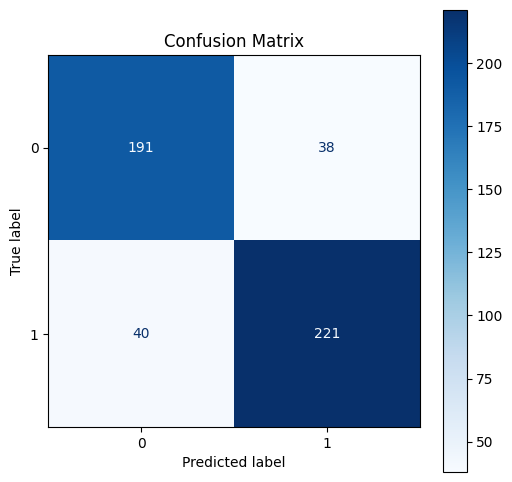

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       229
           1       0.85      0.85      0.85       261

    accuracy                           0.84       490
   macro avg       0.84      0.84      0.84       490
weighted avg       0.84      0.84      0.84       490



In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# show the predictions confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# report: precission, recall, f1 and support
print(classification_report(y_true, y_pred))

In [35]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics)
trainer.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 20706.64it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECT

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.441269,0.420416,0.806122,0.830054,0.778523,0.888889
2,0.358472,0.411921,0.814286,0.819802,0.848361,0.793103


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=400, training_loss=0.46993446588516236, metrics={'train_runtime': 2069.9819, 'train_samples_per_second': 3.086, 'train_steps_per_second': 0.193, 'total_flos': 400492026250080.0, 'train_loss': 0.46993446588516236, 'epoch': 2.0})

In [40]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


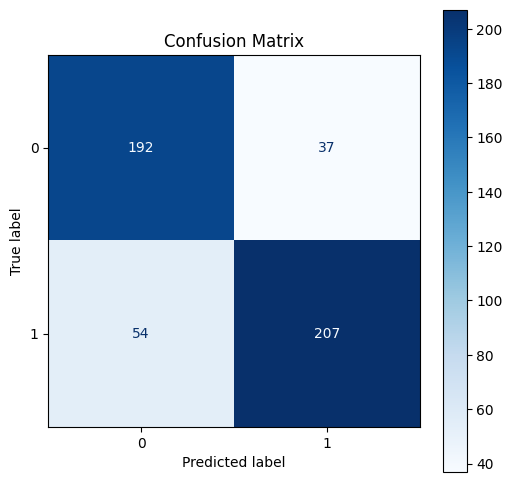

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       229
           1       0.85      0.79      0.82       261

    accuracy                           0.81       490
   macro avg       0.81      0.82      0.81       490
weighted avg       0.82      0.81      0.81       490



In [41]:
# show the predictions confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# report: precission, recall, f1 and support
print(classification_report(y_true, y_pred))

In [42]:
logs = pd.DataFrame(trainer.state.log_history)
logs.to_csv('trainer_log_history.csv')
logs.head(10)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_precision,eval_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.691743,3.713590,9.000000e-07,0.05,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.700707,3.823269,1.900000e-06,0.10,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.693341,2.681674,2.900000e-06,0.15,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.673511,7.061186,3.900000e-06,0.20,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.674673,2.582843,4.900000e-06,0.25,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.672911,4.904677,5.900000e-06,0.30,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.650088,4.441578,6.900000e-06,0.35,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.649542,4.890467,7.900000e-06,0.40,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.620033,4.091640,8.900000e-06,0.45,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.547389,4.328914,9.900000e-06,0.50,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


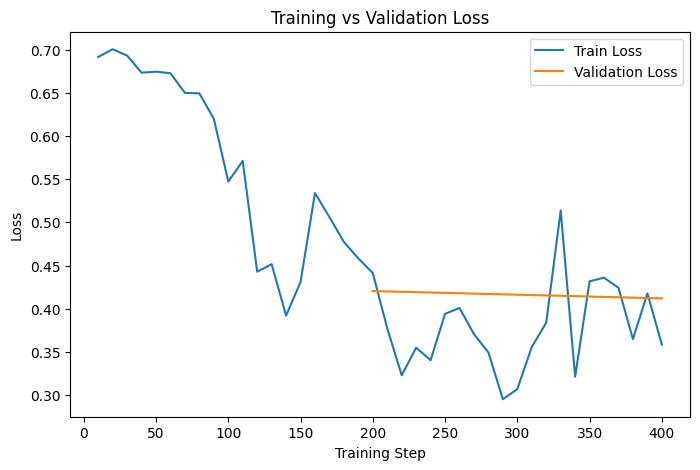

In [43]:
train_loss = logs[logs.loss.notna()]
eval_loss = logs[logs.eval_loss.notna()]

plt.figure(figsize=(8,5))
plt.plot(train_loss.step, train_loss.loss, label='Train Loss')
plt.plot(eval_loss.step, eval_loss.eval_loss, label='Validation Loss')
plt.xlabel('Training Step'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(); plt.show()

## Análisis de errores

In [44]:
error_df = test.copy()
error_df['true_label'] = y_true
error_df['predicted_label'] = y_pred
error_df = error_df[['tweet_clean', 'true_label', 'predicted_label']]
error_df.head(10)

,tweet_clean,true_label,predicted_label
0,[USER] [USER] No me acuerdo de los detalles de...,1,1
1,[USER] lo digo cada pocos dias y lo repito: TO...,0,0
2,Also mientras les decia eso la señalaba y deci...,1,1
3,"And all people killed, attacked, harassed by ...",0,0
4,On this world press freedom day I’m thinking o...,0,0
5,[USER] [USER] [USER] [USER] [USER] La izquierd...,1,1
6,[USER] [USER] Uyyy a q huele? Apesta a xenofob...,1,1
7,Con 25 Leones🦁 y 500 más en las gradas🗣!! eko ...,0,0
8,[USER] [USER] [USER] Me gustaría saber que fut...,1,1
9,[USER] El hombre perfecto para estas mujeres s...,1,1


### Falsos positivos

In [45]:
pd.set_option('display.max_colwidth', None)
false_positives = error_df[(error_df.true_label == 0) & (error_df.predicted_label == 1)]
print(f'Número de falsos positivos: {len(false_positives)}')
false_positives.head(10)

Número de falsos positivos: 37


,tweet_clean,true_label,predicted_label
21,"[USER] tal cual, rompemos el obelisco, quemamos muñecos con la cara de Jake Gyllenhaal al grito de you were tossing me the car keys fuck the patriarchy key chain on the ground y agarrate cuando arranque con dear John te traigo la cabeza de ese en una pica",0,1
22,Agarré un desodorante sin querer que se llama Patrichs y pensé que decía Patriarchy jajsjsj olor a VARON,0,1
34,"Si usted está pensando en votar r3chazo, le recuedo que Cecila Morel, ex primera dama, le da miedito que se deje de abusar del pueblo, por que ella dijo...“Vamos a tener que disminuir nuestros privilegios y compartir con los demás”...con que dejen de robar ya estariamos!",0,1
38,"[USER] Que no somos animales para reproducirnos sin consciencia, dejando vástagos por el mundo sin preocuparnos de lo que han de vestir, comer y recibir como educación. Una ""sobrepoblación"" de un hogar espiritual y materialmente inadecuado puede ser causa de males como el abuso sexual.",0,1
48,"[USER] CalvoAh diablos no me denuncies por acoso sexual 😭😭Pero fuera bromas, que tiene que ver una cosa con la otra yo tampoco entiendo nada tiene sentido [URL]",0,1
49,Dios mío oh padre libranos cada día de:°Los accidentes automovilístico. °Los robos.°El acoso.°La infidelidad. °El homicidio/ feminicidio. °El abuso policial.°El abuso. °El desempleo.°El secuestro en Haití.°La guerra de Putin con Ucrania.°Los desastres naturales.,0,1
62,"[USER] [USER] si asesinar mujeres embarazadas , bombardear niños y sacar los ojos a estudiantes, pero con los actores armados si son cagado no a otro perro con ese hueso",0,1
82,Os confieso q cada vez q veo una foto de orslok 2015 se me caen las bragas,0,1
98,alguien de cadiz capital q busque compañera d piso o chacha d la limpieza solo necesito cama y ducha el resto me apaño,0,1
100,"Que difícil tener a chacha en face, todas las semanas tengo que adivinar quien es el nuevo perfil con nombre raro😂",0,1


### Falsos negativos

In [46]:
false_negatives = error_df[(error_df.true_label == 1) & (error_df.predicted_label == 0)]
print(f'Número de falsos negativos: {len(false_negatives)}')
false_negatives.head(10)

Número de falsos negativos: 54


,tweet_clean,true_label,predicted_label
14,[USER] Micromachismo me recuerda a cuando en South park el directo PC gritaba MICROAGRESION!,1,0
20,"[USER] 22 años, posiblemente una bufanda roja, QUIEN TE LASTIMÓ MAR???? DECINOS QUE LO AGARRAMOS, FUCK THE PATRIARCHY ah",1,0
30,"Absuelto, si, pero, quién le devuelve su vida?. Cuanto daño el pvto yo si te creo [USER] [USER] comunismo es miseria presunciondeinocenci a la reunion secreta [URL]",1,0
39,"ahora que me relaciono de una manera más libre y menos normativa sufro menos esas violencias sistemáticas del amor romántico, pero aún así sufro las secuelas de haber experimentado tanto abuso en el pasado",1,0
58,seguir idealizando y romantizando características sexo corporales adeptas al androcentrismo y a la masculinidad.,1,0
77,"en vivo Conferencia ""Barreras invisibles para madres trabajadoras"", impartida por la Mtra. Virginia Shaday Gutiérrez León [URL] [USER] [USER]",1,0
79,"""hip dips are ok &lt;3"" y sube una foto de sus hip dips casi imperceptibles pero con el polo todo subido para que se le vea la cinturita, el culaso y su thigh gap XDDD body positivity mis pelotas :)",1,0
80,Les encanta mamar de body positivity hasta que es alguien flacx. Dejen de opinar sobre el cuerpo de lxs demás🤫,1,0
89,"Brecha salarial de género, un reflejo de la sociedad. La visión de Fernanda Vicente y Desafío 10X.[URL] [URL]",1,0
91,"Lanzamos equi rutas con el propósito de incrementar la participación de las mujeres en el sector laboral, vinculación en cargos de liderazgo y reducir la brecha salarial de género. 👩🏽‍💼👩🏽‍💻¡Únete con tu organización a esta ipg! ➡️ [URL] [URL]",1,0
